<a href="https://colab.research.google.com/github/Rithikha-21/stock-price-forecasting/blob/main/Stock_Price_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1031/113692586.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1031/113692586.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['Close'] = data['Close'].fillna(method='ffill')


Price           Close       High        Low       Open       Volume
Ticker           AAPL       AAPL       AAPL       AAPL         AAPL
Date                                                               
2015-01-02  24.214890  24.682222  23.776350  24.671147  212818400.0
2015-01-03  24.214890        NaN        NaN        NaN          NaN
2015-01-04  24.214890        NaN        NaN        NaN          NaN
2015-01-05  23.532719  24.064282  23.346673  23.984547  257142000.0
2015-01-06  23.534935  23.794071  23.173914  23.596950  263188400.0


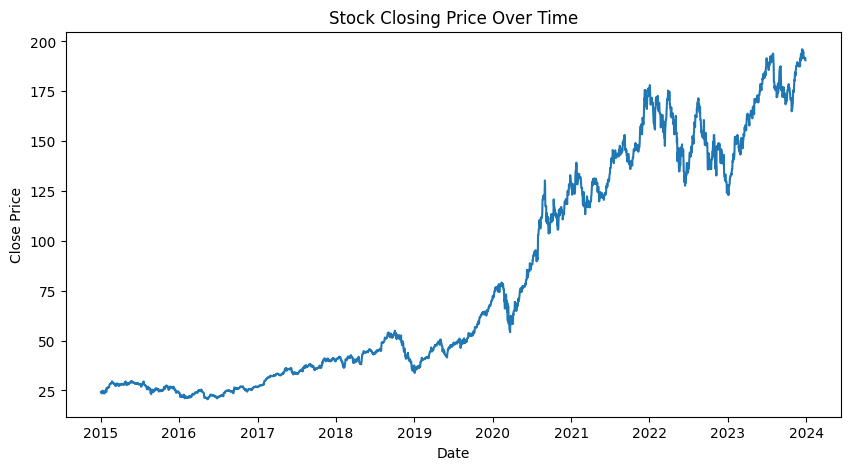

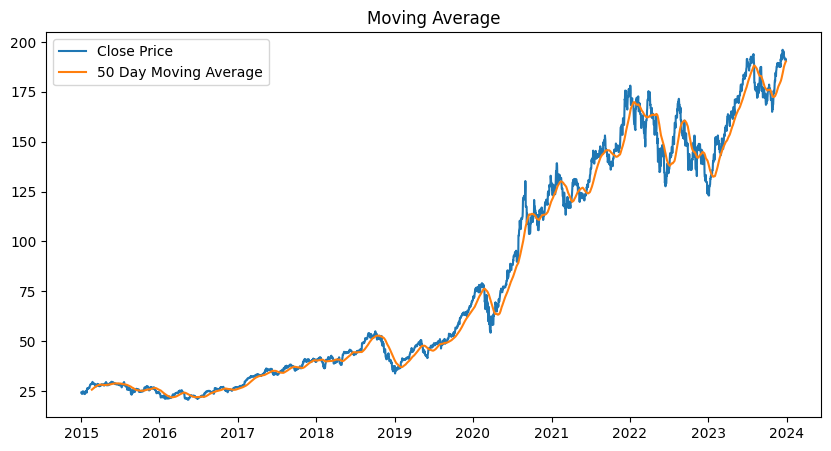

2023-12-30    190.601015
2023-12-31    190.629888
2024-01-01    190.610531
2024-01-02    190.615332
2024-01-03    190.638429
2024-01-04    190.635567
2024-01-05    190.634981
2024-01-06    190.635638
2024-01-07    190.635183
2024-01-08    190.634706
2024-01-09    190.634813
2024-01-10    190.634816
2024-01-11    190.634801
2024-01-12    190.634819
2024-01-13    190.634828
2024-01-14    190.634825
2024-01-15    190.634825
2024-01-16    190.634825
2024-01-17    190.634825
2024-01-18    190.634825
2024-01-19    190.634825
2024-01-20    190.634825
2024-01-21    190.634825
2024-01-22    190.634825
2024-01-23    190.634825
2024-01-24    190.634825
2024-01-25    190.634825
2024-01-26    190.634825
2024-01-27    190.634825
2024-01-28    190.634825
Freq: D, Name: predicted_mean, dtype: float64


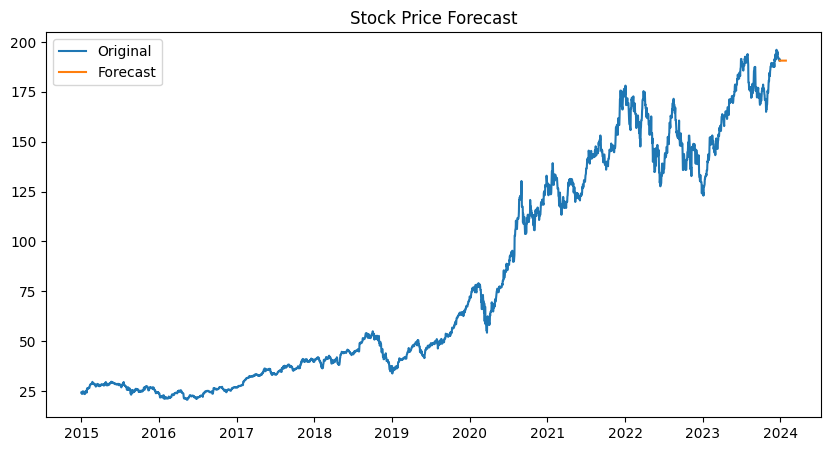

In [8]:
# Install libraries
!pip install yfinance
!pip install pandas
!pip install matplotlib
!pip install statsmodels

# Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Download stock data
data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

# Fix date index frequency
data.index = pd.to_datetime(data.index)
data = data.asfreq('D')

# Fill missing values
data['Close'] = data['Close'].fillna(method='ffill')

# Show first rows
print(data.head())

# Plot closing price
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

# Moving Average
data['MA50'] = data['Close'].rolling(window=50).mean()

plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA50'], label='50 Day Moving Average')
plt.legend()
plt.title("Moving Average")
plt.show()

# Build ARIMA Model
model = ARIMA(data['Close'], order=(5,1,0))
model_fit = model.fit()

# Forecast next 30 days
forecast = model_fit.forecast(steps=30)
print(forecast)

# Create future dates
future_dates = pd.date_range(start=data.index[-1], periods=30, freq='D')

# Plot forecast
plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Original')
plt.plot(future_dates, forecast, label='Forecast')
plt.legend()
plt.title("Stock Price Forecast")
plt.show()